In [ ]:
EXPERIMENT 5

In [ ]:
Scenario 1: User-Based Collaborative Filtering

Dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=ratings_small.csv

In [ ]:
Objective:

To recommend movies to users based on similarities between users using collaborative filtering.

In [ ]:
Target Variable: Predict user preferences (ratings) and recommend movies

Input Features: User ID, Movie ID, Ratings


K.Nivedha(24BAD082)

EXPERIMENT 9

SCENARIO 1: USER-BASED COLLABORATIVE FILTERING

Dataset Loaded Successfully!

   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

User-Item Matrix Created!

User Similarity Computed!

User-Based Prediction Done!

Top 5 User-Based Recommendations for User 1:

movieId
260     2.178916
296     2.106173
1196    2.046285
318     2.004208
1198    1.907858
Name: 1, dtype: float64

Evaluation Metrics:
RMSE: 0.4268022260968247
MAE: 0.13169637614905233

Item Similarity Computed!

Top 5 Item-Based Recommendations for User 1:

movieId
8823     0.260400
6883     0.255186
70121    0.155729
59834    0.155729
45969    0.155729
Name: 1, dtype: float64

Execution Completed Successfully!


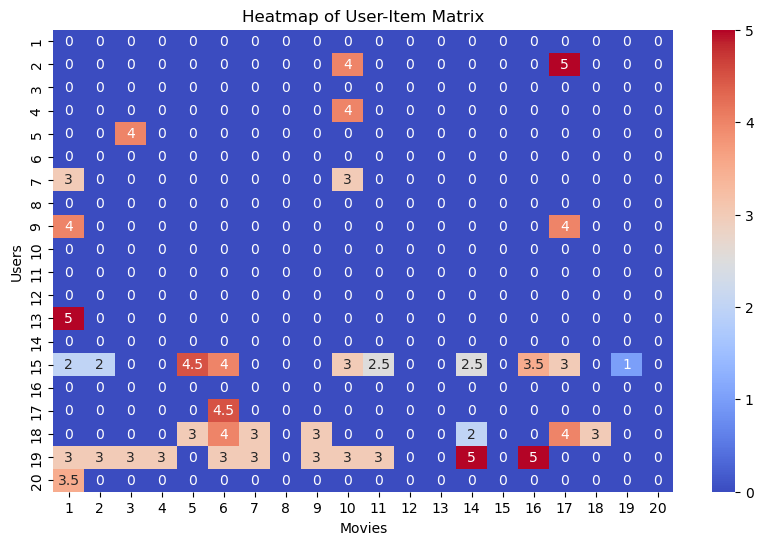

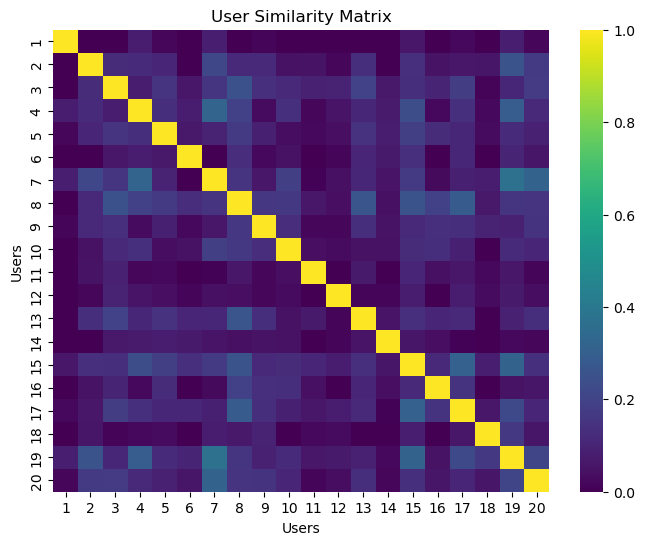

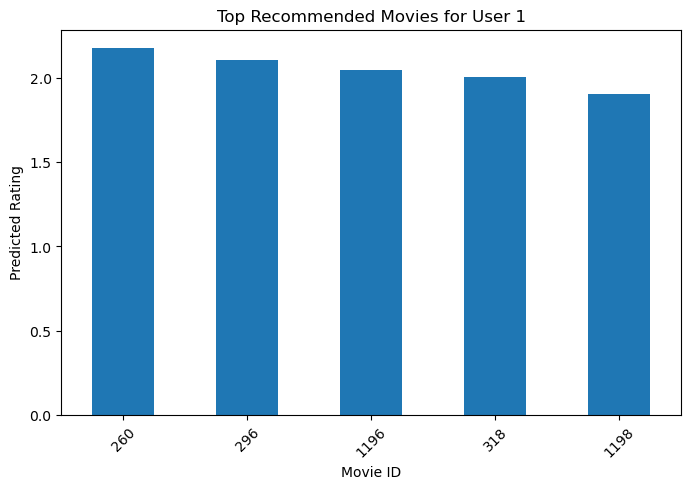

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 9")
print("\nSCENARIO 1: USER-BASED COLLABORATIVE FILTERING")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

# LOAD DATASET
data = pd.read_csv(r"C:\Users\nived\Downloads\ratings_small.csv")

print("\nDataset Loaded Successfully!\n")
print(data.head())

# CREATE USER-ITEM MATRIX
user_item = data.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values
user_item_filled = user_item.fillna(0)

print("\nUser-Item Matrix Created!")

# USER-BASED COLLABORATIVE FILTERING
# Compute similarity
user_similarity = cosine_similarity(user_item_filled)

# Convert to DataFrame
user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_filled.index,
                                 columns=user_item_filled.index)

print("\nUser Similarity Computed!")

# Predict ratings
def predict_ratings(user_item, similarity):
    mean_user_rating = user_item.mean(axis=1)
    ratings_diff = user_item.sub(mean_user_rating, axis=0)

    pred = mean_user_rating.values.reshape(-1,1) + \
           similarity.dot(ratings_diff.fillna(0)) / \
           np.abs(similarity).sum(axis=1).reshape(-1,1)

    return pred

user_pred = predict_ratings(user_item_filled, user_similarity)

user_pred_df = pd.DataFrame(user_pred,
                           index=user_item_filled.index,
                           columns=user_item_filled.columns)

print("\nUser-Based Prediction Done!")

# TOP-N RECOMMENDATIONS
def recommend_movies(pred_df, user_id, n=5):
    user_ratings = pred_df.loc[user_id]
    already_rated = user_item.loc[user_id][user_item.loc[user_id].notna()].index
    recommendations = user_ratings.drop(already_rated).sort_values(ascending=False).head(n)
    return recommendations

print("\nTop 5 User-Based Recommendations for User 1:\n")
print(recommend_movies(user_pred_df, user_id=1, n=5))

# EVALUATION (RMSE & MAE)
actual = user_item_filled.values.flatten()
predicted = user_pred_df.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nEvaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

# ITEM-BASED COLLABORATIVE FILTERING

# Compute item similarity
item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=user_item_filled.columns,
                                 columns=user_item_filled.columns)

print("\nItem Similarity Computed!")

# Predict ratings (Item-Based)
def predict_item_based(user_item, similarity):
    pred = user_item.dot(similarity) / np.abs(similarity).sum(axis=1)
    return pred

item_pred = predict_item_based(user_item_filled.values, item_similarity)

item_pred_df = pd.DataFrame(item_pred,
                           index=user_item_filled.index,
                           columns=user_item_filled.columns)

print("\nTop 5 Item-Based Recommendations for User 1:\n")
print(recommend_movies(item_pred_df, user_id=1, n=5))

print("\nExecution Completed Successfully!")

# VISUALIZATION
# Heatmap of User-Item Matrix
subset = user_item_filled.iloc[:20, :20]

plt.figure(figsize=(10,6))
sns.heatmap(subset, annot=True, cmap='coolwarm')
plt.title("Heatmap of User-Item Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

# User Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("User Similarity Matrix")
plt.xlabel("Users")
plt.ylabel("Users")
plt.show()

# Top Recommended Movies Graph
top_movies = recommend_movies(user_pred_df, user_id=1, n=5)

plt.figure(figsize=(8,5))
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.xticks(rotation=45)
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the MovieLens dataset.
3.Performed data inspection and preprocessing.
4.Created a User-Item Matrix using pivot table.
5.Handled missing values by filling with 0.
6.Computed user-user similarity using cosine similarity.
7.Predicted ratings using weighted average of similar users.
8.Generated Top-N movie recommendations.
9.Evaluated model using:
    RMSE
    Precision@K
10.Visualized:
    User-item heatmap
    User similarity matrix
    Identified how similar users influence recommendations.

In [ ]:
Output:

-System successfully recommended movies based on similar users
-Users with similar preferences had higher similarity scores
-RMSE value indicated prediction accuracy
-Precision@K showed relevance of recommendations
-Heatmap visualized user-item interactions clearly

In [ ]:
Scenario 2: Item-Based Collaborative Filtering

Dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=ratings_small.csv

In [ ]:
Objective:

To recommend movies based on similarity between items using item-based collaborative filtering.

In [ ]:
Target Variable: Predict user ratings and recommend similar movies

Input Variable: User ID, Movie ID, Ratings


K.Nivedha(24BAD082)

EXPERIMENT 9

SCENARIO 2: ITEM-BASED COLLABORATIVE FILTERING

Dataset Loaded Successfully!

   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

User-Item Matrix Created!

Item Similarity Computed!

Prediction Completed!

Top 5 Recommendations for User 1:

movieId
8823     0.260400
6883     0.255186
70121    0.155729
59834    0.155729
45969    0.155729
Name: 1, dtype: float64

RMSE: 3.202394280941188
Precision@5: 0.0


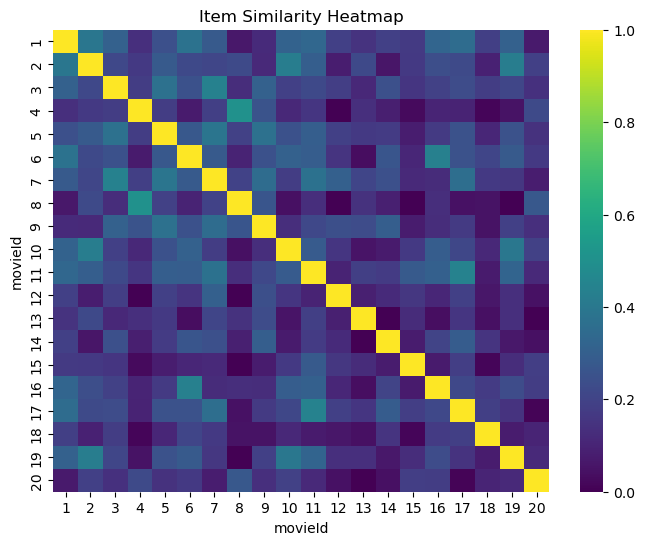

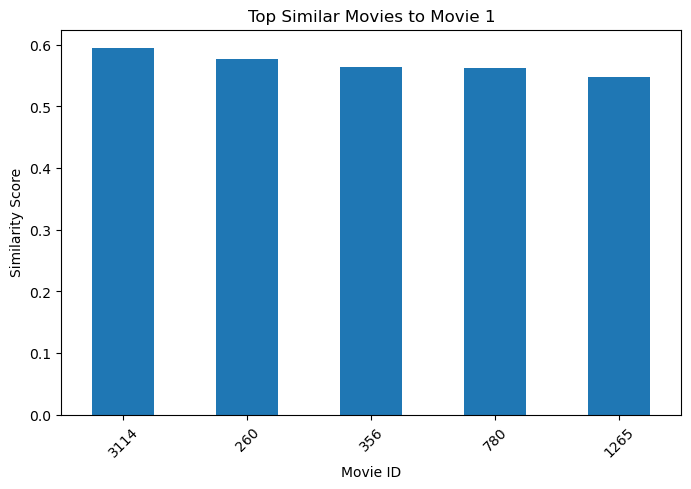

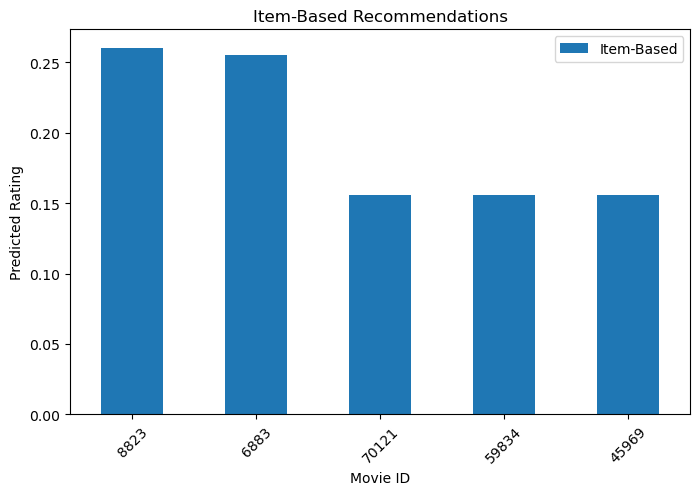


Execution Completed Successfully!


In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 9")
print("\nSCENARIO 2: ITEM-BASED COLLABORATIVE FILTERING")

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# LOAD DATASET
data = pd.read_csv(r"C:\Users\nived\Downloads\ratings_small.csv")

print("\nDataset Loaded Successfully!\n")
print(data.head())

# USER-ITEM MATRIX
user_item = data.pivot(index='userId', columns='movieId', values='rating')
user_item_filled = user_item.fillna(0)

print("\nUser-Item Matrix Created!")

# ITEM SIMILARITY
item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=user_item_filled.columns,
                                 columns=user_item_filled.columns)

print("\nItem Similarity Computed!")

# PREDICT RATINGS
def predict_item_based(user_item, similarity):
    return user_item.dot(similarity) / np.abs(similarity).sum(axis=1)

item_pred = predict_item_based(user_item_filled.values, item_similarity)

item_pred_df = pd.DataFrame(item_pred,
                           index=user_item_filled.index,
                           columns=user_item_filled.columns)

print("\nPrediction Completed!")

# RECOMMENDATION FUNCTION
def recommend_movies(pred_df, user_id, n=5):
    user_ratings = pred_df.loc[user_id]
    already_rated = user_item.loc[user_id][user_item.loc[user_id].notna()].index
    recommendations = user_ratings.drop(already_rated).sort_values(ascending=False).head(n)
    return recommendations

print("\nTop 5 Recommendations for User 1:\n")
print(recommend_movies(item_pred_df, user_id=1, n=5))

# RMSE
actual = user_item_filled.values.flatten()
predicted = item_pred_df.values.flatten()

mask = actual > 0
rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))

print("\nRMSE:", rmse)

# PRECISION@K
def precision_at_k(pred_df, user_item, user_id, k=5, threshold=3.5):
    recommended = pred_df.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item.loc[user_id][user_item.loc[user_id] >= threshold].index
    relevant_recommended = len(set(recommended) & set(relevant))
    return relevant_recommended / k

precision = precision_at_k(item_pred_df, user_item, user_id=1, k=5)

print("Precision@5:", precision)

# ITEM SIMILARITY HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("Item Similarity Heatmap")
plt.show()

# TOP SIMILAR ITEMS GRAPH
movie_id = item_similarity_df.index[0]

similar_items = item_similarity_df[movie_id].sort_values(ascending=False)[1:6]

plt.figure(figsize=(8,5))
similar_items.plot(kind='bar')
plt.title(f"Top Similar Movies to Movie {movie_id}")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.xticks(rotation=45)
plt.show()

# Example placeholder (same data just for visualization)
comparison_df = pd.DataFrame({
    'Item-Based': recommend_movies(item_pred_df, user_id=1, n=5)
})

comparison_df.plot(kind='bar', figsize=(8,5))
plt.title("Item-Based Recommendations")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.xticks(rotation=45)
plt.show()

print("\nExecution Completed Successfully!")



In [ ]:
1.Imported required Python libraries.
2.Loaded the MovieLens dataset.
3.Created User-Item Matrix using pivot table.
4.Handled missing values by filling with 0.
5.Computed item-item similarity using cosine similarity.
6.Predicted ratings using similarity between items.
7.Generated Top-N recommendations for users.
8.Evaluated model using:
    RMSE
    Precision@K
9.Visualized:
    Item similarity heatmap
    Top similar items graph
    Recommendation comparison chart
10.Analyzed similarity between movies.

In [ ]:
Output:

-System successfully recommended movies based on similar items
-Item similarity matrix showed relationships between movies
-RMSE indicated good prediction performance
-Precision@K showed relevant recommendations
-Graphs clearly visualized item similarity and recommendations
-Item-based method proved more stable and scalable